# 04 — Model Selection with Cross-Validation

> **All About Cross-Validation**, Notebook 4 of 4.
> *How do I choose hyperparameters without fooling myself?*

The first three notebooks used CV to **measure**. This one uses CV to **choose** — to pick the
hyperparameters that make a model best. Every tuning method here works the same way underneath:
propose a configuration, **score it with cross-validation**, repeat, keep the winner.

We cover the four search strategies you'll actually meet, newest sklearn tool included:

| Strategy | How it proposes the next config | Best for |
|----------|--------------------------------|----------|
| **Grid Search** | every combination in a hand-made grid | ≤ 3 params, exhaustive |
| **Random Search** | sample from distributions | many params, limited budget |
| **Successive Halving** | start many cheap, promote survivors | large candidate pools |
| **Bayesian (GP & TPE)** | model past results, propose smartly | expensive models, big spaces |

And then the part most tutorials skip — the one that separates a rigorous engineer from a
Kaggle-leaderboard tourist: **nested cross-validation**, the only honest way to report how well
your *tuned* model will actually do.

Dataset: **German Credit** again (small ⇒ tuning noise and the nested-CV effect are visible).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)
RS = 42

from cv_datasets import load_credit, feature_types
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

X, y = load_credit()
num_cols, cat_cols = feature_types(X)

# Leak-proof pipeline (NB01 rule): preprocessing is tuned/refit inside every fold.
def base_pipeline():
    pre = ColumnTransformer([("num", StandardScaler(), num_cols),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])
    return Pipeline([("pre", pre), ("rf", RandomForestClassifier(random_state=RS, n_jobs=-1))])

inner_cv = StratifiedKFold(5, shuffle=True, random_state=1)   # scores each candidate
print(f"German Credit: {X.shape}, positive rate {y.mean():.0%}")
print("All searches tune the Random Forest and score candidates with 5-fold ROC-AUC.")

German Credit: (1000, 20), positive rate 30%
All searches tune the Random Forest and score candidates with 5-fold ROC-AUC.


## Section 1 — Grid Search: try everything

`GridSearchCV` takes the Cartesian product of the values you list and evaluates **every** combo
with CV. Guaranteed to find the best point *in your grid* — but the cost explodes: 3 params ×
3 values each = 27 configs, add a 4th and it's 81. It's the right tool only when the grid is small.

Evaluated 27 configs in 12.8s
Best AUC 0.795  with  {'rf__max_depth': 10, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}


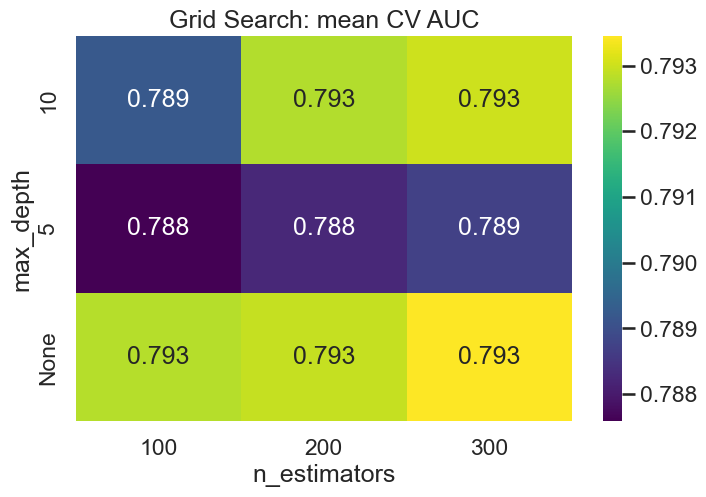

In [2]:
from sklearn.model_selection import GridSearchCV

grid = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [5, 10, None],
    "rf__min_samples_split": [2, 5, 10],
}
t0 = time.time()
gs = GridSearchCV(base_pipeline(), grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1).fit(X, y)
grid_time = time.time() - t0

print(f"Evaluated {len(gs.cv_results_['params'])} configs in {grid_time:.1f}s")
print(f"Best AUC {gs.best_score_:.3f}  with  {gs.best_params_}")

# Heatmap: mean AUC over the two most important axes (averaged over min_samples_split).
res = pd.DataFrame(gs.cv_results_)
res["depth"] = res["param_rf__max_depth"].astype(str)
piv = res.pivot_table(index="depth", columns="param_rf__n_estimators",
                      values="mean_test_score", aggfunc="mean")
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set(title="Grid Search: mean CV AUC", xlabel="n_estimators", ylabel="max_depth")
plt.show()

### How to read this chart

- Each cell is the cross-validated AUC for that corner of the grid. The search just returns the
  brightest cell.
- Notice how **flat** it is — most cells are within ~0.01 of each other. Random Forests are
  forgiving; the "best" config wins by a hair. That flatness is a recurring theme below.
- Grid Search's weakness: it spends equal effort on obviously-bad regions, and adding one more
  parameter multiplies the cost. Which motivates…

## Section 2 — Random Search: sample, don't enumerate

`RandomizedSearchCV` draws a fixed number of configs from **distributions**. The Bergstra &
Bengio (2012) result: when only a few parameters actually matter, random search finds a good
config **far faster** than grid, because it never wastes trials tiling the unimportant axes.
Same budget, broader coverage.

Sampled 20 configs from a 4-D space in 4.7s
Best AUC 0.800  with  {'rf__max_depth': 26, 'rf__min_samples_leaf': 3, 'rf__min_samples_split': 3, 'rf__n_estimators': 137}


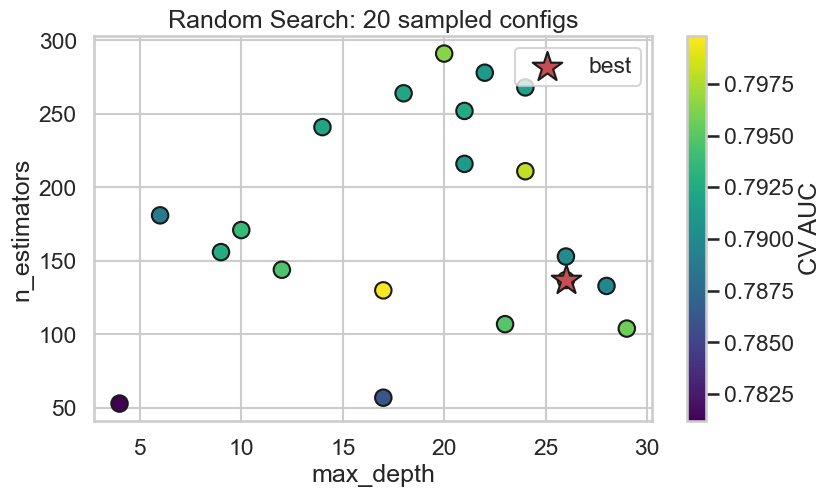

In [3]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

distributions = {
    "rf__n_estimators": randint(50, 300),
    "rf__max_depth": randint(3, 30),
    "rf__min_samples_split": randint(2, 20),
    "rf__min_samples_leaf": randint(1, 10),
}
t0 = time.time()
rs = RandomizedSearchCV(base_pipeline(), distributions, n_iter=20, cv=inner_cv,
                        scoring="roc_auc", random_state=RS, n_jobs=-1).fit(X, y)
random_time = time.time() - t0

print(f"Sampled 20 configs from a 4-D space in {random_time:.1f}s")
print(f"Best AUC {rs.best_score_:.3f}  with  {rs.best_params_}")

rr = pd.DataFrame(rs.cv_results_)
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(rr["param_rf__max_depth"], rr["param_rf__n_estimators"],
                c=rr["mean_test_score"], cmap="viridis", s=140, edgecolor="k")
ax.scatter(rs.best_params_["rf__max_depth"], rs.best_params_["rf__n_estimators"],
           marker="*", s=500, color="#C44E52", edgecolor="k", label="best", zorder=5)
plt.colorbar(sc, label="CV AUC")
ax.set(title="Random Search: 20 sampled configs", xlabel="max_depth", ylabel="n_estimators")
ax.legend(); plt.show()

### How to read this chart

- Each dot is one randomly drawn configuration; colour is its CV AUC; the ★ is the winner.
- With just **20 samples** across a 4-D space, random search reaches essentially the same AUC as
  the 27-cell grid — and it explored *four* parameters, not three, in less time.
- **Rule of thumb:** beyond 2–3 parameters, reach for random search before grid.

## Section 3 — Successive Halving: don't fully train the losers

`HalvingRandomSearchCV` (sklearn's tournament) is smarter about *budget*. It starts **many**
candidates on a **small** slice of data, keeps the top fraction, and gives the survivors more
data each round — so hopeless configs die cheap and only contenders ever run at full size.

In [4]:
from sklearn.experimental import enable_halving_search_cv  # noqa: F401  (unlocks the import below)
from sklearn.model_selection import HalvingRandomSearchCV

t0 = time.time()
hs = HalvingRandomSearchCV(base_pipeline(), distributions, factor=3, cv=inner_cv,
                           scoring="roc_auc", random_state=RS, n_jobs=-1).fit(X, y)
halving_time = time.time() - t0

sched = pd.DataFrame({"iteration": range(len(hs.n_candidates_)),
                      "candidates": hs.n_candidates_,
                      "resources (samples)": hs.n_resources_})
print(sched.to_string(index=False))
print(f"\nBest AUC {hs.best_score_:.3f} in {halving_time:.1f}s")
print("Each round: ~1/factor of candidates survive, each gets ~factor x more data.")

 iteration  candidates  resources (samples)
         0          50                   20
         1          17                   60
         2           6                  180
         3           2                  540

Best AUC 0.801 in 16.8s
Each round: ~1/factor of candidates survive, each gets ~factor x more data.


### How to read this table

- Read top to bottom: **many candidates on few samples** → **few candidates on many samples**.
  The pool shrinks by ~`factor` (3) each round while the data per candidate grows by ~`factor`.
- Total compute is a fraction of "train every candidate on all the data," yet the winner is
  usually as good. Use it when you have a **large candidate pool** and training is expensive.
- Caveat: a config that only shines on the full dataset can be culled early on the small slice —
  halving trades a little robustness for a lot of speed.

## Section 4 — Bayesian optimization: learn from past trials

Grid, random, and halving are (mostly) **memoryless** — the next config ignores what earlier
ones scored. **Bayesian optimization** builds a cheap *surrogate model* of "config → score" and
uses it to propose the next config where improvement is most likely, balancing **exploit**
(near known-good points) and **explore** (uncertain regions). Two industry-standard flavours:

- **scikit-optimize `BayesSearchCV`** — a **Gaussian Process** surrogate, sklearn-style API.
- **Optuna** — a **Tree-structured Parzen Estimator (TPE)**; models "good" vs "bad" trial
  distributions. Scales to big/awkward spaces; the Kaggle/production default.

In [5]:
from skopt import BayesSearchCV
from skopt.space import Integer
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

space = {
    "rf__n_estimators": Integer(50, 300),
    "rf__max_depth": Integer(3, 30),
    "rf__min_samples_split": Integer(2, 20),
    "rf__min_samples_leaf": Integer(1, 10),
}

t0 = time.time()
skopt_search = BayesSearchCV(base_pipeline(), space, n_iter=20, cv=inner_cv,
                             scoring="roc_auc", random_state=RS, n_jobs=-1).fit(X, y)
skopt_time = time.time() - t0
print(f"skopt (GP)  best AUC {skopt_search.best_score_:.3f} in {skopt_time:.1f}s")

from sklearn.model_selection import cross_val_score
def objective(trial):
    params = {
        "rf__n_estimators": trial.suggest_int("rf__n_estimators", 50, 300),
        "rf__max_depth": trial.suggest_int("rf__max_depth", 3, 30),
        "rf__min_samples_split": trial.suggest_int("rf__min_samples_split", 2, 20),
        "rf__min_samples_leaf": trial.suggest_int("rf__min_samples_leaf", 1, 10),
    }
    return cross_val_score(base_pipeline().set_params(**params), X, y,
                           cv=inner_cv, scoring="roc_auc").mean()

t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RS))
study.optimize(objective, n_trials=20)
optuna_time = time.time() - t0
print(f"Optuna (TPE) best AUC {study.best_value:.3f} in {optuna_time:.1f}s")

skopt (GP)  best AUC 0.800 in 17.6s


Optuna (TPE) best AUC 0.798 in 35.5s


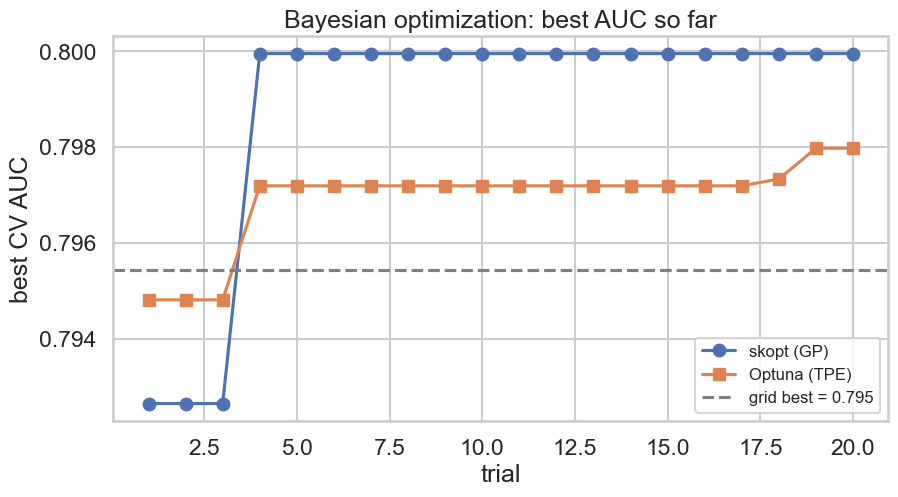

In [6]:
# Convergence: best-score-so-far vs number of trials.
skopt_hist = pd.DataFrame(skopt_search.cv_results_)["mean_test_score"].cummax()
optuna_hist = pd.Series([t.value for t in study.trials]).cummax()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(skopt_hist)+1), skopt_hist, "o-", label="skopt (GP)", color="#4C72B0")
ax.plot(range(1, len(optuna_hist)+1), optuna_hist, "s-", label="Optuna (TPE)", color="#DD8452")
ax.axhline(gs.best_score_, ls="--", color="gray", label=f"grid best = {gs.best_score_:.3f}")
ax.set(title="Bayesian optimization: best AUC so far", xlabel="trial", ylabel="best CV AUC")
ax.legend(fontsize=12); plt.show()

### How to read this chart

- Each line is **best-score-so-far**, so it only ever steps up. A curve that climbs fast then
  flattens means the optimizer found a good region early and confirmed nothing beats it.
- Both land within a whisker of the grid's best — on a small, forgiving problem, Bayesian methods
  mostly buy **efficiency** (fewer trials to get there), not a higher ceiling. Their edge grows
  when each trial is *expensive* (deep nets, big data) and the space is large.
- **GP (skopt)** is elegant for small continuous spaces; **TPE (Optuna)** handles large,
  conditional, mixed spaces and ships with pruning/parallelism — why it dominates in practice.

## Section 5 — So which search should I use?

Line them all up on the same problem: best AUC vs wall-clock.

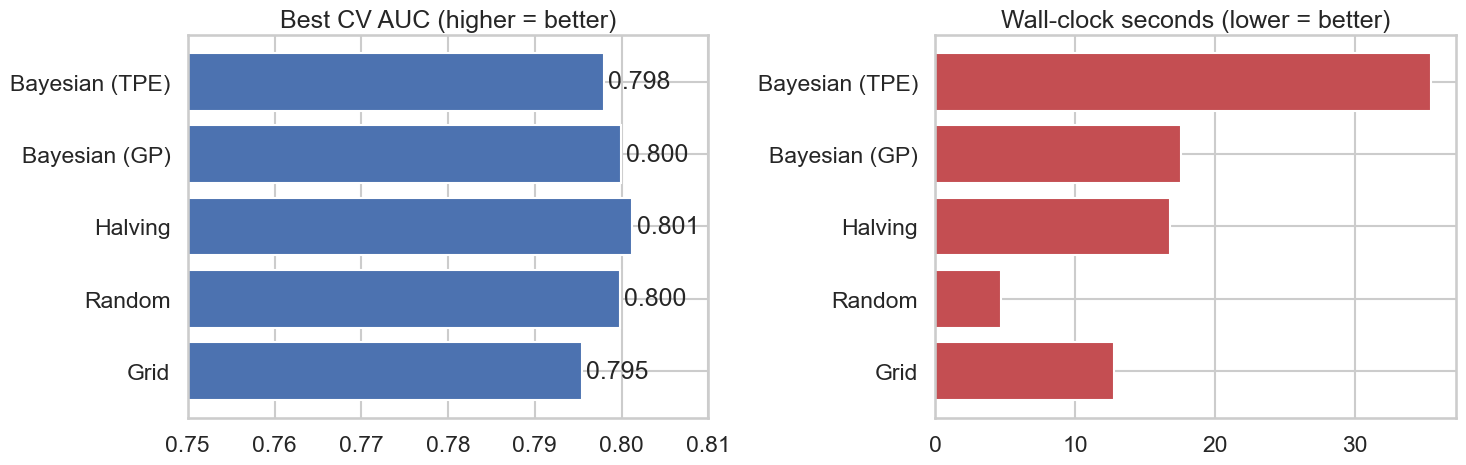

        method  best_AUC   seconds  configs
          Grid  0.795429 12.785019       27
        Random  0.799810  4.717967       20
       Halving  0.801232 16.787341       75
 Bayesian (GP)  0.799952 17.551378       20
Bayesian (TPE)  0.797976 35.463593       20


In [7]:
summary = pd.DataFrame([
    ("Grid",             gs.best_score_,          grid_time,   len(gs.cv_results_["params"])),
    ("Random",           rs.best_score_,          random_time, 20),
    ("Halving",          hs.best_score_,          halving_time, int(np.sum(hs.n_candidates_))),
    ("Bayesian (GP)",    skopt_search.best_score_, skopt_time,  20),
    ("Bayesian (TPE)",   study.best_value,        optuna_time, 20),
], columns=["method", "best_AUC", "seconds", "configs"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(summary["method"], summary["best_AUC"], color="#4C72B0", edgecolor="white")
axes[0].set(title="Best CV AUC (higher = better)", xlim=(0.75, 0.81))
for i, v in enumerate(summary["best_AUC"]):
    axes[0].text(v+0.0005, i, f"{v:.3f}", va="center")
axes[1].barh(summary["method"], summary["seconds"], color="#C44E52", edgecolor="white")
axes[1].set(title="Wall-clock seconds (lower = better)")
plt.tight_layout(); plt.show()
print(summary.to_string(index=False))

### How to read this chart

- **All five methods finish within ~0.01 AUC of each other.** The honest headline of most tuning
  jobs: past a sensible default, hyperparameter search yields *diminishing returns*.
- The methods differ mostly in **how efficiently** they get there. On this small dataset the
  simple ones even look fastest, because Bayesian bookkeeping isn't worth it yet — that flips as
  models get expensive.
- The dangerous mistake isn't picking the "wrong" search. It's what we do next: **reporting the
  winning score as the model's performance.** That number is biased upward, and Section 6 fixes it.

## Section 6 — Nested cross-validation: the honest final score 🎯

Here's the subtle trap. We just evaluated ~20–27 configs and reported **the best** CV score.
But we *chose* that config **because** it scored highest on those very folds. Taking the max over
many configurations evaluated on the same data is a **selection bias** — the winner is partly
skilled and partly lucky. So `best_score_` **overstates** how the tuned model will do on new data.

**Nested CV** removes the bias with two loops:

- **Inner loop** — does the tuning (exactly what Sections 1–4 did), on the training part only.
- **Outer loop** — scores the *whole tuning procedure* on a fold it never touched.

The outer scores estimate "build a model by tuning, then deploy" — honestly, error bars included.

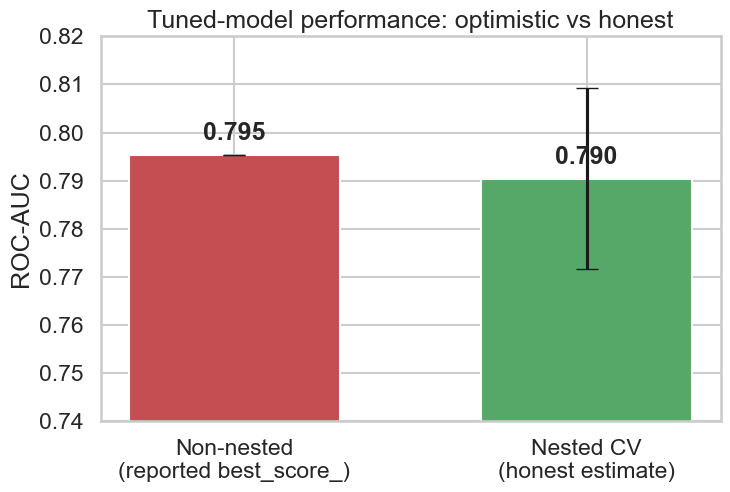

Non-nested best_score_ : 0.795   (what most people report)
Nested CV estimate     : 0.790 +/- 0.019   (honest)
Optimism (selection bias): +0.005


In [8]:
# Non-nested: tune once, report the winning inner score (the biased-but-common number).
non_nested = gs.best_score_

# Nested: the ENTIRE GridSearchCV is re-run inside each outer fold; we score on held-out folds.
outer_cv = StratifiedKFold(5, shuffle=True, random_state=RS)
tuner = GridSearchCV(base_pipeline(), grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)
nested_scores = cross_val_score(tuner, X, y, cv=outer_cv, scoring="roc_auc")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(["Non-nested\n(reported best_score_)", "Nested CV\n(honest estimate)"],
       [non_nested, nested_scores.mean()],
       yerr=[0, nested_scores.std()], capsize=8,
       color=["#C44E52", "#55A868"], edgecolor="white", width=0.6)
ax.set(title="Tuned-model performance: optimistic vs honest", ylabel="ROC-AUC",
       ylim=(0.74, 0.82))
for i, v in enumerate([non_nested, nested_scores.mean()]):
    ax.text(i, v+0.003, f"{v:.3f}", ha="center", fontweight="bold")
plt.show()

print(f"Non-nested best_score_ : {non_nested:.3f}   (what most people report)")
print(f"Nested CV estimate     : {nested_scores.mean():.3f} +/- {nested_scores.std():.3f}   (honest)")
print(f"Optimism (selection bias): {non_nested - nested_scores.mean():+.3f}")

### How to read this chart — and when it bites

- The green bar is **always ≤** the red one: selection bias only ever inflates. Here it's a
  modest **~0.01**, but two things change that:
  - **More configs searched** → bigger bias (more chances to get lucky — the *winner's curse*).
  - **Less data** → bigger bias (folds are noisier, luck matters more).
  On a small dataset with a heavy hyperparameter sweep, this gap can reach several points — the
  difference between "ships" and "should never have shipped."
- The nested bar also carries an **error bar** (±0.02) that the single `best_score_` completely
  hides. That spread is real uncertainty about your tuned model.
- **The rule:** *tune inside the CV you report, never on it.* Use `best_score_` to **pick**
  hyperparameters; use **nested CV** to **report** how the tuned model will perform. Then refit on
  all the data for the model you actually deploy.

## Key takeaways

1. **Every tuner is CV in a loop:** propose → cross-validate → keep the best.
2. **Grid** for tiny spaces; **Random** once you have >2–3 params; **Halving** for large candidate
   pools; **Bayesian (GP/TPE)** when each trial is expensive and the space is big.
3. **Diminishing returns are normal** — all five methods landed within ~0.01 AUC. Don't mistake
   tuning for the main event.
4. **Nested CV is non-negotiable for an honest number.** `best_score_` is a selection score, not
   a generalization estimate; the bias grows with search size and shrinks with data.

---

## 🏁 The series, in one page

| Notebook | The one thing to remember |
|----------|---------------------------|
| **01 Foundations & Leakage** | Evaluate on unseen data; put every data-dependent step in a `Pipeline`, or you manufacture fake skill (0.82 AUC from pure noise). |
| **02 The K-Fold Family** | `StratifiedKFold` is the classification default; repeat to pin the mean; LOOCV is just extreme K. |
| **03 Grouped & Time-Aware** | If entities recur, split on the entity (R² 0.91→−0.57); if time flows, never shuffle it. |
| **04 Model Selection** | Tune with CV, but **report** with **nested** CV. |

> **The golden rule beneath all four:** the data you use to *judge* a model must be data the
> model — and your choices about it — never touched. Every technique in this series is one more
> way to guarantee that.

*Thanks for reading. — All About Cross-Validation*